<a href="https://colab.research.google.com/github/diptomistry/AlgorithmCPP/blob/main/AI_Search_Algo_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [354]:
import heapq
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
from matplotlib import cm



In [355]:
# ─── Problem Setup ──────────────────────────────────────────────────────────────

# Custom grid:
# 0 = free, 1 = obstacle
grid = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # Row 0
    [0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0],  # Row 1
    [0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0],  # Row 2
    [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0],  # Row 3
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # Row 4
]
# Define edge costs for all pairs of neighboring nodes:
edge_costs = {
    # Horizontal edges (same row)
    ((0,0),(0,1)):1, ((0,1),(0,0)):1, ((0,1),(0,2)):1, ((0,2),(0,1)):1,
    ((0,2),(0,3)):1, ((0,3),(0,2)):1, ((0,3),(0,4)):1, ((0,4),(0,3)):1,
    ((0,4),(0,5)):1, ((0,5),(0,4)):1, ((0,5),(0,6)):1, ((0,6),(0,5)):1,
    ((0,6),(0,7)):1, ((0,7),(0,6)):1, ((0,7),(0,8)):1, ((0,8),(0,7)):1,
    ((0,8),(0,9)):1, ((0,9),(0,8)):1, ((0,9),(0,10)):1, ((0,10),(0,9)):1,

    ((1,0),(1,1)):2, ((1,1),(1,0)):2, ((1,2),(1,3)):2, ((1,3),(1,2)):2,
    ((1,3),(1,4)):2, ((1,4),(1,3)):2, ((1,9),(1,10)):2, ((1,10),(1,9)):2,

    ((2,0),(2,1)):2, ((2,1),(2,0)):2, ((2,3),(2,4)):2, ((2,4),(2,3)):2,
    ((2,4),(2,5)):2, ((2,5),(2,4)):2, ((2,5),(2,6)):2, ((2,6),(2,5)):2,
    ((2,6),(2,7)):2, ((2,7),(2,6)):2, ((2,7),(2,8)):2, ((2,8),(2,7)):2,

    ((3,0),(3,1)):2, ((3,1),(3,0)):2, ((3,2),(3,3)):2, ((3,3),(3,2)):2,
    ((3,3),(3,4)):2, ((3,4),(3,3)):2, ((3,4),(3,5)):2, ((3,5),(3,4)):2,
    ((3,5),(3,6)):2, ((3,6),(3,5)):2, ((3,6),(3,7)):2, ((3,7),(3,6)):2,
    ((3,7),(3,8)):2, ((3,8),(3,7)):2, ((3,8),(3,9)):2, ((3,9),(3,8)):2,

    ((4,0),(4,1)):2, ((4,1),(4,0)):2, ((4,1),(4,2)):2, ((4,2),(4,1)):2,
    ((4,2),(4,3)):2, ((4,3),(4,2)):2, ((4,3),(4,4)):2, ((4,4),(4,3)):2,
    ((4,4),(4,5)):2, ((4,5),(4,4)):2, ((4,5),(4,6)):2, ((4,6),(4,5)):2,
    ((4,6),(4,7)):2, ((4,7),(4,6)):2, ((4,7),(4,8)):2, ((4,8),(4,7)):2,
    ((4,8),(4,9)):2, ((4,9),(4,8)):2, ((4,9),(4,10)):2, ((4,10),(4,9)):2,

    # Vertical edges (row-to-row)
    ((0,0),(1,0)):1, ((1,0),(0,0)):1, ((0,1),(1,1)):3, ((1,1),(0,1)):3,
    ((0,2),(1,2)):1, ((1,2),(0,2)):1, ((0,3),(1,3)):1, ((1,3),(0,3)):1,
    ((0,4),(1,4)):1, ((1,4),(0,4)):1, ((0,10),(1,10)):1, ((1,10),(0,10)):1,

    ((1,0),(2,0)):1, ((2,0),(1,0)):1, ((1,2),(2,2)):3, ((2,2),(1,2)):3,
    ((1,3),(2,3)):1, ((2,3),(1,3)):1, ((1,4),(2,4)):1, ((2,4),(1,4)):1,
    ((1,10),(2,10)):1, ((2,10),(1,10)):1,

    ((2,0),(3,0)):1, ((3,0),(2,0)):1, ((2,3),(3,3)):1, ((3,3),(2,3)):1,
    ((2,4),(3,4)):3, ((3,4),(2,4)):3, ((2,5),(3,5)):1, ((3,5),(2,5)):1,
    ((2,6),(3,6)):1, ((3,6),(2,6)):1, ((2,7),(3,7)):1, ((3,7),(2,7)):1,
    ((2,10),(3,10)):1, ((3,10),(2,10)):1,

    ((3,0),(4,0)):1, ((4,0),(3,0)):1, ((3,1),(4,1)):1, ((4,1),(3,1)):1,
    ((3,10),(4,10)):1, ((4,10),(3,10)):1
}
grid = np.array(grid)
height, width = grid.shape

start = (3, 0)
goal  = (2, 6)

def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def neighbors(node):
    for dr, dc in [(1,0),(-1,0),(0,1),(0,-1)]: #a loop over the four possible directions from a grid cell — down, up, right, and left.
        nr, nc = node[0] + dr, node[1] + dc
        if 0 <= nr < height and 0 <= nc < width and grid[nr,nc] == 0:#Check if the new node is within grid bounds and is not an obstacle,will stop as soon as goal is founc
            yield (nr, nc) #returns one value at a time
            #result.append((nr, nc))
    #return result.(This returns a full list of all valid neighbors at once)

# For UCS/A*/Weighted A* (edge costs)
def neighbors_cost(node):
    r,c = node
    for dr,dc in [(1,0),(-1,0),(0,1),(0,-1)]:
        nr, nc = r+dr, c+dc
        if 0 <= nr < height and 0 <= nc < width and grid[nr][nc] == 0:
            cost = edge_costs.get((node, (nr,nc)), 1)
            yield ( (nr, nc), cost )

In [356]:
# Search templates
def reconstruct(came_from, found): #builds the final path from the start to the goal
    path = []
    if found:
        cur = goal
        while cur is not None: #Start from the goal node,Keep tracing back from goal → previous node → previous... until reaching start (which has came_from[start] = None)
            path.append(cur)
            cur = came_from[cur] #came_from[cur] retrieves the node that led to the current node cur during the search.
        path.reverse() #Since we built the path from goal → start, we reverse it to get start → goal.
    return path

In [357]:
# BFS
def bfs(grid, start, goal):
    from collections import deque
    frontier = deque([start]) # creates a double-ended queue (deque) with the starting position, holds the tuple (3, 0) initially,queue of nodes that are waiting to be explored
    came_from = {start: None} #dictionary or map
    expanded=[] #stores all the nodes that have been removed from the frontier and explored
    t0=time.perf_counter()
    found=False
    while frontier:
        node = frontier.popleft() #pop (3,0)
        expanded.append(node) #Add to expanded
        if node==goal:
            found=True
            break
        for nb in neighbors(node):
            if nb not in came_from: #checks if the neighbor nb has already been visited,(4,0), (2,0), (3,1) → All valid
                came_from[nb]=node #recording the node from which the current neighbor (nb) was reached
                frontier.append(nb) #Add them to frontier: [(4,0), (2,0), (3,1)]
    t1=time.perf_counter()
    return {'name':'BFS', 'path':reconstruct(came_from, found), 'expanded':expanded,
            'time':t1-t0,'memory':len(came_from),'search_space':len(expanded),
            'complete':found,'optimal':True}

In [358]:
# DFS
def dfs(grid, start, goal):
    frontier=[start] #lifo
    came_from={start:None}
    expanded=[] #already visited
    t0=time.perf_counter()
    found=False
    while frontier:
        node=frontier.pop()
        if node in expanded: #avoids going back to the start
            continue
        expanded.append(node)
        if node==goal:
            found=True
            break
        for nb in neighbors(node):
            #print(f"Checking {nb} from {node}")
            if nb not in came_from: #the left side of the colon. (2,0) ignores as it is already in this dict.After we finish the entire subtree under (3,0), when the stack pops (2,0), we’ll expand it
                came_from[nb]=node
                frontier.append(nb)
    t1=time.perf_counter()
    #print("Expanded nodes:", expanded)
    #print("Came_From",came_from)
    return {'name':'DFS','path':reconstruct(came_from, found),'expanded':expanded,
            'time':t1-t0,'memory':len(came_from),'search_space':len(expanded),
            'complete':found,'optimal':False}

In [359]:
# Depth-Limited Search
def dls(grid, start, goal, limit):
    expanded=[]
    came_from={start:None}
    t0=time.perf_counter()
    def recursive(node, depth):
        expanded.append(node)
        if node==goal:
            return True
        if depth>=limit:
            return False
        for nb in neighbors(node):
            if nb not in came_from:
                came_from[nb]=node
                if recursive(nb, depth+1):
                    return True
        return False
    found=recursive(start,0)
    t1=time.perf_counter()
    # print(f"Expanded nodes (DLS, limit={limit}):", expanded)
    return {'name':f'DLS(limit={limit})','path':reconstruct(came_from,found),'expanded':expanded,
            'time':t1-t0,'memory':len(came_from),'search_space':len(expanded),
            'complete':found,'optimal':False}


In [360]:
# Iterative Deepening Search
def ids(grid, start, goal, max_limit=20):
    for limit in range(max_limit+1):
        res=dls(grid, start, goal, limit)
        if res['complete']:
            res['name']='IDS'
            return res
    return {'name':'IDS','path':[],'expanded':[],'time':0,'memory':0,
            'search_space':0,'complete':False,'optimal':False}

In [361]:
# Uniform Cost Search
def ucs(grid, start, goal):
    frontier = [(0, start)] #Starts with the start node at cost 0,frontier is a heapified list where each element is a tuple:(cost_to_reach_node, node_coordinates)
                            #For Example (5, (2, 2)),   # Cost 5 to reach (2, 2)
    heapq.heapify(frontier) #priority queue (min-heap),ensures that the lowest cost (or value) is always at the front (or "top") of the priority queue and will pop first
    came_from   = {start: None}
    cost_so_far = {start: 0}
    expanded    = []
    t0          = time.perf_counter()
    found       = False

    while frontier:
        current_cost, node = heapq.heappop(frontier) #Retrieves and removes the tuple with the smallest cost ,current_cost = 5;node = (2, 2)
        if current_cost > cost_so_far[node]:
            continue
        expanded.append(node)
        if node == goal:
            found = True
            break

        # Use the cost‐aware neighbor function:
        for nb, edge_cost in neighbors_cost(node):
            new_cost = cost_so_far[node] + edge_cost
            if new_cost < cost_so_far.get(nb, float('inf')):#If nb is not yet in cost_so_far, it returns infinity. If we haven’t visited nb yet, then its current cost is considered infinite
                cost_so_far[nb] = new_cost
                came_from[nb]   = node
                heapq.heappush(frontier, (new_cost, nb))

    t1 = time.perf_counter()
    return {
        'name':         'UCS',
        'path':         reconstruct(came_from, found),
        'expanded':     expanded,
        'time':         t1 - t0,
        'memory':       len(came_from),
        'search_space': len(expanded),
        'complete':     found,
        'optimal':      True
    }


In [362]:
# ─── Greedy Best-First Search ──────────────────────────────────────────────────

def best_first(grid, start, goal):
    frontier = [(manhattan(start, goal), start)]
    came_from = {start: None}
    expanded = []
    t0 = time.perf_counter()
    found = False

    while frontier:
        _, node = heapq.heappop(frontier)
        expanded.append(node)
        if node == goal:
            found = True
            break
        for nb in neighbors(node):
            if nb not in came_from:
                came_from[nb] = node
                heapq.heappush(frontier, (manhattan(nb, goal), nb))

    t1 = time.perf_counter()
    # reconstruct path
    path = []
    if found:
        cur = goal
        while cur is not None:
            path.append(cur)
            cur = came_from[cur]
        path.reverse()

    return {
        'name':       'Best-First',
        'path':       path,
        'expanded':   expanded,
        'time':       t1 - t0,
        'memory':     len(came_from),
        'search_space': len(expanded),
        'complete':   found,
        'optimal':    False  # Greedy BF is not guaranteed optimal
    }

In [363]:
# ─── A* Search ─────────────────────────────────────────────────────────────────

def astar(grid, start, goal):
    frontier = [(manhattan(start, goal), 0, start)]
    came_from = {start: None}
    g_score   = {start: 0}
    expanded  = []
    t0 = time.perf_counter()
    found = False

    while frontier:
        _, cost, node = heapq.heappop(frontier)
        expanded.append(node)
        if node == goal:
            found = True
            break
        for nb in neighbors(node):
            tentative_g = g_score[node] + 1
            if tentative_g < g_score.get(nb, float('inf')):
                came_from[nb] = node
                g_score[nb] = tentative_g
                f = tentative_g + manhattan(nb, goal)
                heapq.heappush(frontier, (f, tentative_g, nb))

    t1 = time.perf_counter()
    # reconstruct path
    path = []
    if found:
        cur = goal
        while cur is not None:
            path.append(cur)
            cur = came_from[cur]
        path.reverse()

    return {
        'name':        'A*',
        'path':        path,
        'expanded':    expanded,
        'time':        t1 - t0,
        'memory':      len(came_from),
        'search_space': len(expanded),
        'complete':    found,
        'optimal':     True   # A* with admissible heuristic is optimal
    }

In [364]:
# Weighted A*
def weighted_astar(grid, start, goal, weight=2.0):
    frontier=[(manhattan(start,goal)*weight, 0, start)]
    heapq.heapify(frontier)
    came_from={start:None}
    g_score={start:0}
    expanded=[]
    t0=time.perf_counter()
    found=False
    while frontier:
        _,cost,node=heapq.heappop(frontier)
        expanded.append(node)
        if node==goal:
            found=True
            break
        for nb in neighbors(node):
            tg=g_score[node]+1
            if tg<g_score.get(nb,float('inf')):
                came_from[nb]=node
                g_score[nb]=tg
                f=tg + weight*manhattan(nb,goal)
                heapq.heappush(frontier,(f,tg,nb))
    t1=time.perf_counter()
    return {'name':f'Weighted A*(w={weight})','path':reconstruct(came_from,found),
            'expanded':expanded,'time':t1-t0,'memory':len(came_from),
            'search_space':len(expanded),'complete':found,'optimal':False}

In [365]:
# ─── Run and Compare ────────────────────────────────────────────────────────────

bfs_res = bfs(grid,start,goal)
dfs_res = dfs(grid,start,goal)
dls_res = dls(grid,start,goal,limit=10)
ids_res = ids(grid,start,goal)
ucs_res = ucs(grid,start,goal)
bf_res    = best_first(grid, start, goal)
astar_res = astar    (grid, start, goal)
weighted_astar_res = weighted_astar (grid,start,goal,2.0)



df = pd.DataFrame([{
    'Algorithm':   r['name'],
    'Complete':    r['complete'],
    'Optimal':     r['optimal'],
    'Time (s)':    r['time'],
    'Nodes Stored':r['memory'],
    'Nodes Expanded':r['search_space'],
    'Path Length': len(r['path'])
} for r in (bfs_res,dfs_res,dls_res,ids_res,ucs_res,bf_res,astar_res,weighted_astar_res)])

print(df)

            Algorithm  Complete  Optimal  Time (s)  Nodes Stored  \
0                 BFS      True     True  0.000153            32   
1                 DFS      True    False  0.000077            36   
2       DLS(limit=10)     False    False  0.000051            26   
3                 IDS      True    False  0.000037            26   
4                 UCS      True     True  0.000128            30   
5          Best-First      True    False  0.000067            33   
6                  A*      True     True  0.000125            28   
7  Weighted A*(w=2.0)      True    False  0.000078            29   

   Nodes Expanded  Path Length  
0              30           12  
1              33           28  
2              26            0  
3              26           12  
4              28           12  
5              28           26  
6              26           12  
7              24           12  


In [366]:
def show_initial_grid(grid, start, goal, title="Initial Grid"):
    grid = np.array(grid)
    img = np.full((*grid.shape, 3), 0.85)  # light gray background

    for r in range(grid.shape[0]):
        for c in range(grid.shape[1]):
            if grid[r, c] == 1:
                img[r, c] = [0, 0, 0]  # obstacle = black

    img[start] = [0.0, 1.0, 1.0]  # start = cyan
    img[goal] = [0.0, 1.0, 0.0]   # goal = green

    fig, ax = plt.subplots(figsize=(grid.shape[1] * 0.5, grid.shape[0] * 0.5))
    ax.imshow(img, extent=[0, grid.shape[1], grid.shape[0], 0])

    # Draw white grid lines
    for x in range(grid.shape[1] + 1):
        ax.axvline(x, color='white', linewidth=1)
    for y in range(grid.shape[0] + 1):
        ax.axhline(y, color='white', linewidth=1)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)

    # Legend
    legend_patches = [
        mpatches.Patch(color=[0.0, 1.0, 1.0], label='Start (Cyan)'),
        mpatches.Patch(color=[0.0, 1.0, 0.0], label='Goal (Green)'),
        mpatches.Patch(color=[0, 0, 0],       label='Obstacle (Black)'),
        mpatches.Patch(color=[0.85, 0.85, 0.85], label='Free Cell (Light Gray)'),
    ]
    ax.legend(handles=legend_patches, loc='lower center',
              bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=False)

    plt.show()

In [367]:

def visualize_search(grid, start, goal, result, title):
    grid = np.array(grid)
    img = np.full((*grid.shape, 3), 0.85)  # light gray background

    # draw obstacles
    for r in range(grid.shape[0]):
        for c in range(grid.shape[1]):
            if grid[r, c] == 1:
                img[r, c] = [0, 0, 0]  # black

    # heatmap for expanded nodes
    expanded = result['expanded']
    if expanded:
        heatmap = np.zeros(grid.shape)
        for i, (r, c) in enumerate(expanded):
            heatmap[r, c] = i + 1  # index for order

        max_val = heatmap.max()
        if max_val > 0:
            norm_heatmap = heatmap / max_val
            cmap = plt.get_cmap('YlOrRd') # yellow -> red
            for r in range(grid.shape[0]):
                for c in range(grid.shape[1]):
                    if heatmap[r, c] > 0 and (r, c) != start and (r, c) != goal:
                        img[r, c] = cmap(norm_heatmap[r, c])[:3]  # RGB

    # start and goal
    img[start] = [0.0, 1.0, 1.0]  # cyan (start)
    img[goal] = [0.0, 1.0, 0.0]   # green (goal)

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(grid.shape[1] * 0.5, grid.shape[0] * 0.5))
    ax.imshow(img, extent=[0, grid.shape[1], grid.shape[0], 0])

    # Add white grid lines
    for x in range(grid.shape[1] + 1):
        ax.axvline(x, color='white', linewidth=1)
    for y in range(grid.shape[0] + 1):
        ax.axhline(y, color='white', linewidth=1)

    # Draw arrows for path
    path = result['path']
    for i in range(len(path) - 1):
        (r1, c1) = path[i]
        (r2, c2) = path[i + 1]

        # skip if start or goal
        if (r1, c1) == start or (r2, c2) == goal:
            continue

        ax.arrow(
            c1 + 0.5, r1 + 0.5,
            (c2 - c1), (r2 - r1),
            head_width=0.3, head_length=0.3,
            fc='blue', ec='blue', length_includes_head=True
        )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)

    # Legend
    legend_patches = [
        mpatches.Patch(color=[0.0, 1.0, 1.0], label='Start (Cyan)'),
        mpatches.Patch(color=[0.0, 1.0, 0.0], label='Goal (Green)'),
        mpatches.Patch(color=[0, 0, 0],       label='Obstacle (Black)'),
        mpatches.Patch(color='orange',        label='Expanded (Heatmap)'),
        mpatches.Patch(color='blue',          label='Path Arrow'),
    ]
    ax.legend(handles=legend_patches, loc='lower center',
              bbox_to_anchor=(0.5, -0.15), ncol=5, frameon=False)

    plt.show()

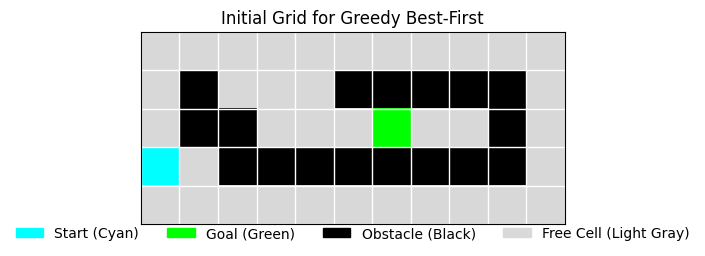

In [368]:
# --- Run and visualize ---
show_initial_grid(grid, start, goal, title="Initial Grid for Greedy Best-First")


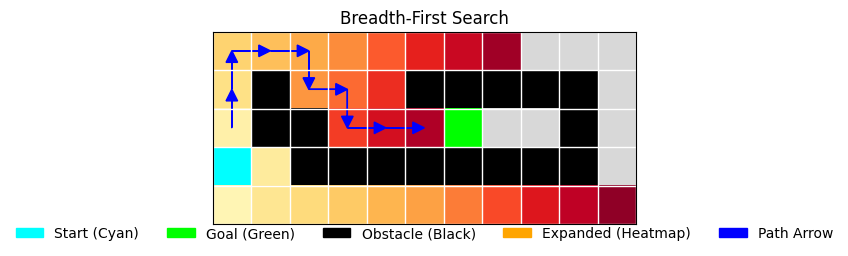

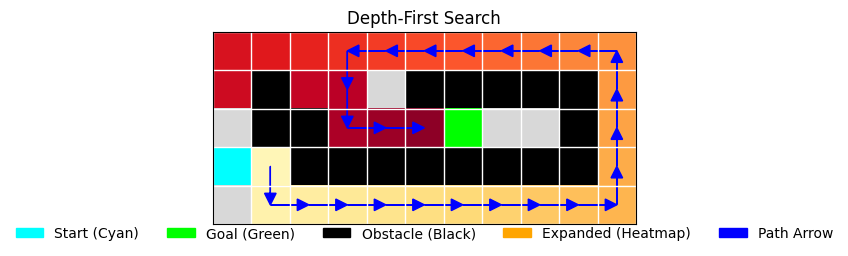

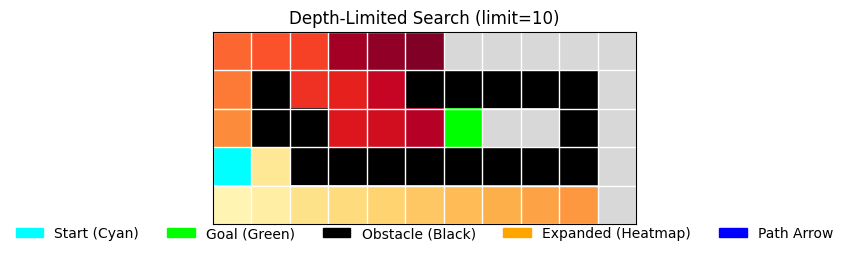

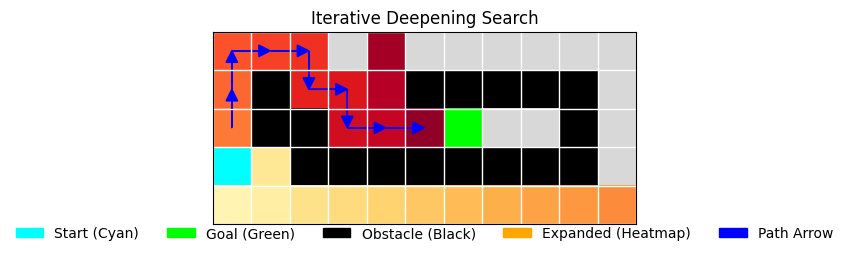

In [369]:
# Visualize each search result
visualize_search(grid, start, goal, bfs_res, 'Breadth-First Search')
visualize_search(grid, start, goal, dfs_res, 'Depth-First Search')
visualize_search(grid, start, goal, dls_res, 'Depth-Limited Search (limit=10)')
visualize_search(grid, start, goal, ids_res, 'Iterative Deepening Search')




Graph With Edge Cost:

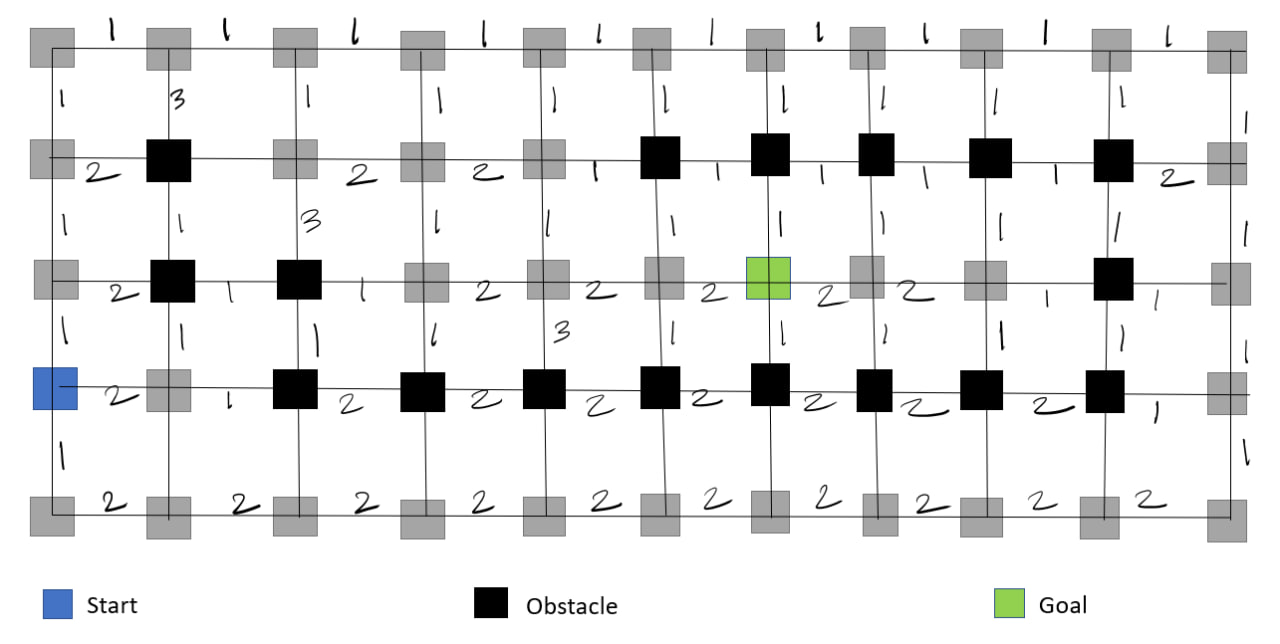

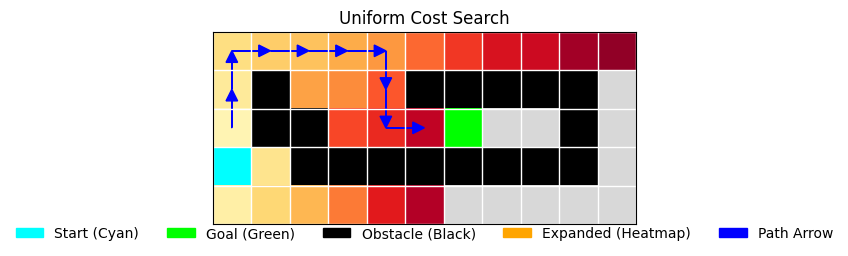

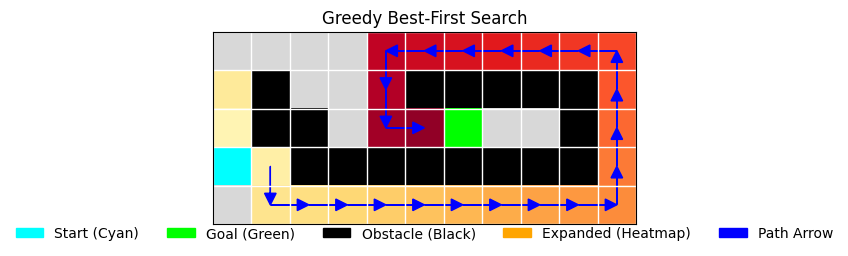

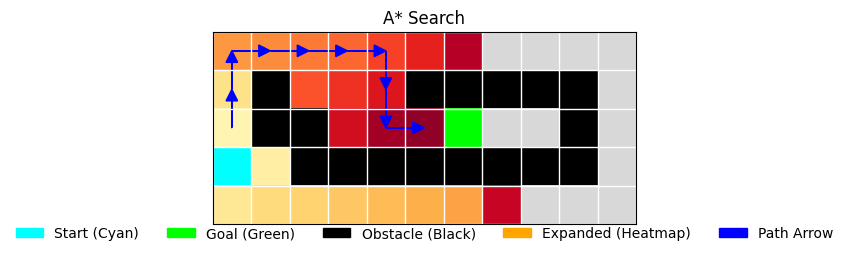

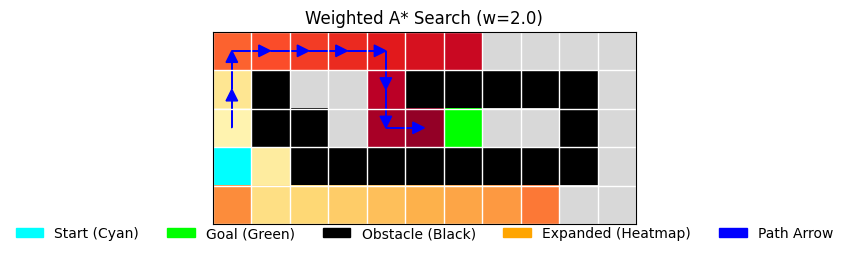

In [370]:
visualize_search(grid, start, goal, ucs_res, 'Uniform Cost Search')
visualize_search(grid, start, goal, bf_res, 'Greedy Best-First Search')
visualize_search(grid, start, goal, astar_res, 'A* Search')
visualize_search(grid, start, goal, weighted_astar_res, 'Weighted A* Search (w=2.0)')